In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

#Quaternion utilities

def hat(v):
    v = np.asarray(v).reshape(3,)
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def unhat(S):
    return 0.5 * np.array([S[2,1]-S[1,2],
                           S[0,2]-S[2,0],
                           S[1,0]-S[0,1]])

H = np.vstack([np.zeros((1,3)), np.eye(3)])

Tquat = np.block([
    [np.array([[1]]), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])

def L(q):
    q = np.asarray(q)
    q0, qv = q[0], q[1:4]
    top = np.hstack([q0, -qv])
    bottom = np.hstack([qv.reshape(3,1), q0*np.eye(3) + hat(qv)])
    return np.vstack([top, bottom])

def R(q):
    q = np.asarray(q)
    return np.block([
        [q[0], -q[1:4]],
        [q[1:4].reshape(3,1), q[0]*np.eye(3) - hat(q[1:4])]
    ])

def G(q):
    return L(q) @ H

def Q(q):
    q = np.asarray(q)
    q = q / np.linalg.norm(q)
    q0, q1, q2, q3 = q
    return np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q0*q2+q1*q3)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q0*q1+q2*q3), 1-2*(q1**2+q2**2)]
    ])

def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)
    if theta < 1e-8:
        return np.hstack([1.0, phi])
    return np.hstack([np.cos(theta), phi * np.sin(theta)/theta])

def logq(q):
    q = np.asarray(q)
    q = q / np.linalg.norm(q)

    if q[0] < 0:
        q = -q

    theta = np.arccos(np.clip(q[0], -1.0, 1.0))
    s = np.linalg.norm(q[1:4])

    if s < 1e-8:
        return np.zeros(3)

    return theta * q[1:4] / s

def qconj(q):
    return Tquat @ q

def qmult(q1, q2):
    return L(q1) @ q2

def normalize_quat(q):
    n = np.linalg.norm(q)
    if not np.isfinite(n) or n < 1e-12:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / n

def attitude_error_deg(q):
    # logq uses half-angle convention, so physical angle = 2*||logq(q)||
    return np.degrees(2*np.linalg.norm(logq(q)))


In [3]:
#########  Orbit Model  ###########
mu_km = 398600.0          # km^3/s^2
mu = mu_km * 1e9          # m^3/s^2, for torque equations
earth_radius_km = 6371.0

def two_body(t, state):
    r = state[0:3]
    v = state[3:6]
    r_norm = np.linalg.norm(r)
    a = -mu_km * r / r_norm**3
    return np.hstack((v, a))

# Approximate TESS orbital radii
rp_km = 108000.0
ra_km = 373000.0

a_km = 0.5 * (rp_km + ra_km)
e = (ra_km - rp_km) / (ra_km + rp_km)

# Start at perigee in the x direction
r0_orbit = np.array([rp_km, 0.0, 0.0])
v_perigee = np.sqrt(mu_km * (2/np.linalg.norm(r0_orbit) - 1/a_km))
v0_orbit = np.array([0.0, v_perigee, 0.0])

orbit_state0 = np.hstack((r0_orbit, v0_orbit))

T_orbit = 2*np.pi*np.sqrt(a_km**3/mu_km)

print(f"TESS-like orbit period from chosen rp/ra: {T_orbit/86400:.2f} days")
print(f"Eccentricity: {e:.3f}")

num_orbits = 3
N = 2500
t_span = (0.0, num_orbits*T_orbit)
t_eval = np.linspace(t_span[0], t_span[1], N)
dt = t_eval[1] - t_eval[0]

orbit_sol = solve_ivp(
    two_body,
    t_span,
    orbit_state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

r_hist_km = orbit_sol.y[0:3, :]
v_hist_km_s = orbit_sol.y[3:6, :]

# Convert to meters for torque equations
r_hist = 1000.0 * r_hist_km

TESS-like orbit period from chosen rp/ra: 13.59 days
Eccentricity: 0.551


In [4]:
#########  Spacecraft Model  ###########
J = np.diag([132.56, 101.64, 89.61]) #Inertia Matrix

# Solar radiation pressure at ~1 AU from lecture notes
P_srp = 4.5e-6       # Pa = N/m^2

# Reflectivity coefficient
Cr = 1.5

# Effective projected SRP area [m^2] (see section 3.4 Surface Discretization in Overleaf)
A_srp = 2.5

# Vector from center of mass to center of pressure in body frame [m].
r_cp_body = np.array([0.10, 0.05, 0.20])

In [5]:
def Bw(x):
    return np.array([
        [1.0, 0.0, 0.0, 1/np.sqrt(3)],
        [0.0, 1.0, 0.0, 1/np.sqrt(3)],
        [0.0, 0.0, 1.0, 1/np.sqrt(3)]
    ])

def steering(x, tau):
    B = Bw(x)
    eps = 1e-8
    u = B.T @ np.linalg.solve(B @ B.T + eps*np.eye(3), tau)
    return u

In [6]:
#######  Environmental Toruqes  ########
def gravity_gradient(q, r_I):
    q = normalize_quat(q)

    C_BI = Q(q)       # body to inertial
    C_IB = C_BI.T     # inertial to body

    r_hat_I = r_I / np.linalg.norm(r_I) # inertial spacecraft position vector from Earth center [m]
    r_body_hat = C_IB @ r_hat_I

    return 3 * mu / np.linalg.norm(r_I)**3 * np.cross(r_body_hat, J @ r_body_hat)

def srp_torque(q):
    #Assumes Sun direction is fixed along ECI +x-axis
    q = normalize_quat(q)

    sun_I_hat = np.array([1.0, 0.0, 0.0])

    C_BI = Q(q)
    C_IB = C_BI.T
    sun_body_hat = C_IB @ sun_I_hat

    F_srp_body = P_srp * Cr * A_srp * sun_body_hat

    return np.cross(r_cp_body, F_srp_body) #

def environmental_torque(q, r_I, include_gg=True, include_srp=True):
    tau = np.zeros(3)

    if include_gg:
        tau += gravity_gradient(q, r_I)

    if include_srp:
        tau += srp_torque(q)

    return tau

In [ ]:
######  Controller Implementation  #######
def controller(x):
    kp = 0.005
    kd = 0.22

    q = normalize_quat(x[0:4])
    w = x[4:7]
    phi = logq(q)

    return -kp*phi - kd*w

####### Dynamics and RK4 integration  #######
def dynamics(x, u, r_I, include_control=True, include_gg=True, include_srp=True):
    q = normalize_quat(x[0:4])
    w = x[4:7]

    if include_control:
        tau_control = Bw(x) @ u
    else:
        tau_control = np.zeros(3)

    tau_env = environmental_torque(q, r_I, include_gg=include_gg, include_srp=include_srp)
    tau_total = tau_control + tau_env

    qdot = 0.5 * G(q) @ w
    wdot = np.linalg.solve(J, tau_total - np.cross(w, J @ w))

    return np.hstack([qdot, wdot])

# Toggle control, gravity gradient, and SRP so that the code can be reused for Problems 2 and 3
def rkstep(x, u, r_I, h, include_control=True, include_gg=True, include_srp=True):
    f1 = dynamics(x, u, r_I, include_control, include_gg, include_srp)
    f2 = dynamics(x + 0.5*h*f1, u, r_I, include_control, include_gg, include_srp)
    f3 = dynamics(x + 0.5*h*f2, u, r_I, include_control, include_gg, include_srp)
    f4 = dynamics(x + h*f3, u, r_I, include_control, include_gg, include_srp)

    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xn[0:4] = normalize_quat(xn[0:4])
    return xn

<h2> Problem 2 <h2>

In [8]:
def simulate_problem2(x0):
    x_none = np.zeros((7, N))
    x_gg = np.zeros((7, N))
    x_srp = np.zeros((7, N))
    x_both = np.zeros((7, N))

    x_none[:, 0] = x0
    x_gg[:, 0] = x0
    x_srp[:, 0] = x0
    x_both[:, 0] = x0

    tau_gg_hist = np.zeros((3, N))
    tau_srp_hist = np.zeros((3, N))
    tau_both_hist = np.zeros((3, N))
    h_accum_hist = np.zeros((3, N))

    u_zero = np.zeros(Bw(x0).shape[1])

    for k in range(N-1):
        r_I = r_hist[:, k]

        q_both = x_both[0:4, k]

        tau_gg_hist[:, k] = gravity_gradient(q_both, r_I)
        tau_srp_hist[:, k] = srp_torque(q_both)
        tau_both_hist[:, k] = tau_gg_hist[:, k] + tau_srp_hist[:, k]

        h_accum_hist[:, k+1] = h_accum_hist[:, k] + tau_both_hist[:, k]*dt

        x_none[:, k+1] = rkstep(
            x_none[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=False, include_srp=False
        )

        x_gg[:, k+1] = rkstep(
            x_gg[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=True, include_srp=False
        )

        x_srp[:, k+1] = rkstep(
            x_srp[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=False, include_srp=True
        )

        x_both[:, k+1] = rkstep(
            x_both[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=True, include_srp=True
        )

    return x_none, x_gg, x_srp, x_both, tau_gg_hist, tau_srp_hist, tau_both_hist, h_accum_hist



<h2> Problem 3 <h2>

In [9]:
# Take MEKF from HW3 (copied directly)
# Number of sensors
m_sun = 1
m_st = 1

# Inertial Sun direction
r_sun_N = np.array([1.0, 0.0, 0.0])
r_sun_N = r_sun_N / np.linalg.norm(r_sun_N)

rng = np.random.default_rng(1)

# Sun sensor parameters
scale_std_sun = 2e-3
misalign_std_sun = 1e-3

M_sun = np.eye(3)
M_sun += np.diag(scale_std_sun * rng.standard_normal(3))

Mis_sun = misalign_std_sun * rng.standard_normal((3,3))
np.fill_diagonal(Mis_sun, 0.0)
M_sun += Mis_sun

b_sun = np.deg2rad(np.array([0.02, -0.01, 0.01]))

sigma_sun = np.deg2rad(1.0)
W_sun = (sigma_sun**2) * np.eye(3)

# Star tracker parameters
sigma_st_arcsec = 50.0
sigma_st = (sigma_st_arcsec / 3600.0) * np.pi / 180.0
W_st_single = (sigma_st**2) * np.eye(3)
W_st = (sigma_st**2) * np.eye(3*m_st)

# Gyro parameters
scale_std_gyro = 5e-4
misalign_std_gyro = 1e-3

Mgyro = np.eye(3)
Mgyro += np.diag(scale_std_gyro * rng.standard_normal(3))

Mis_gyro = misalign_std_gyro * rng.standard_normal((3,3))
np.fill_diagonal(Mis_gyro, 0.0)
Mgyro += Mis_gyro

sigma_gyro = np.deg2rad(0.005)
Wgyro = (sigma_gyro**2) * np.eye(3)

sigma_bias_rw = np.deg2rad(1e-5)
Wbias = (sigma_bias_rw**2) * dt * np.eye(3)

sqrtW_sun = sqrtm(W_sun)
sqrtW_st = sqrtm(W_st)
sqrtWgyro = sqrtm(Wgyro)
sqrtWbias = sqrtm(Wbias)

# MEKF covariance matrices
V = np.block([
    [0.25 * dt**2 * Wgyro, np.zeros((3,3))],
    [np.zeros((3,3)),      Wbias]
])

W = np.block([
    [W_st,                  np.zeros((3*m_st, 3))],
    [np.zeros((3, 3*m_st)), W_sun]
])

def generate_sensor_measurements(x_true, beta_true):
    q_true = normalize_quat(x_true[0:4])
    omega_true = x_true[4:7]

    # Sun sensor measurement
    yideal_sun = Q(q_true).T @ r_sun_N
    y_sun = M_sun @ yideal_sun + b_sun + sqrtW_sun @ np.random.randn(3)
    y_sun = y_sun / np.linalg.norm(y_sun)

    # Star tracker measurement
    w_st = sqrtW_st @ np.random.randn(3*m_st)
    y_st = L(q_true) @ expq(w_st[0:3])
    y_st = y_st / np.linalg.norm(y_st)

    # Propagate true gyro bias as random walk
    beta_next = beta_true + sqrtWbias @ np.random.randn(3)

    # Gyro measurement
    ygyro = Mgyro @ omega_true + beta_next + sqrtWgyro @ np.random.randn(3)

    return y_st, y_sun, ygyro, beta_next

def state_prediction(x, u_gyro, h):
    q = normalize_quat(x[0:4])
    beta = x[4:7]

    omega = u_gyro - beta

    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    qn = normalize_quat(qn)

    return np.hstack([qn, beta])

def state_prediction_deriv(x, u_gyro, h):
    q = normalize_quat(x[0:4])
    beta = x[4:7]

    omega = u_gyro - beta
    delta_q = expq(0.5*h*omega)

    qn = L(q) @ delta_q
    qn = normalize_quat(qn)

    A = np.block([
        [G(qn).T @ R(delta_q) @ G(q), -0.5*h * (G(qn).T @ G(qn))],
        [np.zeros((3,3)),             np.eye(3)]
    ])

    return A

def innovation_combined(x, y_st, y_sun):
    q = normalize_quat(x[0:4])

    # Star tracker innovation
    yk_st = y_st.reshape((4, m_st), order='F')
    z_st = np.zeros((3, m_st))

    for ell in range(m_st):
        z_st[:, ell] = G(q).T @ yk_st[:, ell]

    # Sun sensor innovation
    yhat_sun = Q(q).T @ r_sun_N
    z_sun = y_sun - yhat_sun

    return np.hstack([z_st.reshape(3*m_st, order='F'), z_sun])

def innovation_deriv_combined(x, y_st, y_sun):
    q = normalize_quat(x[0:4])

    # Star tracker Jacobian
    yk_st = y_st.reshape((4, m_st), order='F')
    C_st = np.zeros((3*m_st, 6))

    for ell in range(m_st):
        C_st[3*ell:3*ell+3, 0:3] = H.T @ R(yk_st[:, ell]) @ Tquat @ G(q)

    # Sun sensor Jacobian
    yhat_sun = Q(q).T @ r_sun_N
    C_sun = np.zeros((3, 6))
    C_sun[:, 0:3] = 2 * hat(yhat_sun)

    return np.vstack([C_st, C_sun])

def mekf_step(xfilt_k, P_k, ygyro_k, y_st_next, y_sun_next):
    # Prediction
    xpred = state_prediction(xfilt_k, ygyro_k, dt)
    A = state_prediction_deriv(xfilt_k, ygyro_k, dt)
    Ppred = A @ P_k @ A.T + V

    # Innovation/update
    z = innovation_combined(xpred, y_st_next, y_sun_next)
    C = innovation_deriv_combined(xpred, y_st_next, y_sun_next)

    S = C @ Ppred @ C.T + W
    K = Ppred @ C.T @ np.linalg.inv(S)

    delta_x = -K @ z
    phi = delta_x[0:3]

    delta_q = np.hstack([np.sqrt(max(0, 1 - phi.T @ phi)), phi])

    q_update = L(xpred[0:4]) @ delta_q
    q_update = normalize_quat(q_update)

    beta_update = xpred[4:7] + delta_x[3:6]

    xfilt_next = np.hstack([q_update, beta_update])

    P_next = (np.eye(6) - K@C) @ Ppred @ (np.eye(6) - K@C).T + K @ W @ K.T

    return xfilt_next, P_next


def mekf_control_state(xfilt_k, ygyro_k):
    q_est = normalize_quat(xfilt_k[0:4])
    beta_est = xfilt_k[4:7]

    omega_est = ygyro_k - beta_est

    return np.hstack([q_est, omega_est])

In [10]:
def simulate_problem3_with_mekf(x0):

    x = np.zeros((7, N))
    xfilt = np.zeros((7, N))
    xcontrol_est = np.zeros((7, N))

    P = np.zeros((6, 6, N))

    y_st_hist = np.zeros((4, N))
    y_sun_hist = np.zeros((3, N))
    ygyro_hist = np.zeros((3, N))
    beta_true_hist = np.zeros((3, N))

    u_hist = np.zeros((Bw(x0).shape[1], N))
    tau_cmd_hist = np.zeros((3, N))
    tau_control_hist = np.zeros((3, N))
    tau_env_hist = np.zeros((3, N))
    err_deg_hist = np.zeros(N)
    est_err_deg_hist = np.zeros(N)

    # True initial state
    x[:, 0] = x0

    # True initial gyro bias
    beta_true_hist[:, 0] = np.deg2rad(np.array([0.05, -0.03, 0.02]))

    # Slightly perturb true initial attitude
    xfilt[0:4, 0] = normalize_quat(x0[0:4] + 0.01*np.random.randn(4))

    # Initial bias estimate
    xfilt[4:7, 0] = np.zeros(3)

    # Initial covariance
    P[:,:,0] = np.diag([
        (5*np.pi/180)**2,
        (5*np.pi/180)**2,
        (5*np.pi/180)**2,
        (0.01)**2,
        (0.01)**2,
        (0.01)**2
    ])

    # Generate initial sensor measurements
    y_st_hist[:, 0], y_sun_hist[:, 0], ygyro_hist[:, 0], beta_true_hist[:, 0] = generate_sensor_measurements(
        x[:, 0],
        beta_true_hist[:, 0]
    )

    for k in range(N-1):
        r_I = r_hist[:, k]

        # Use current MEKF state + current gyro measurement to form controller state
        x_est_control = mekf_control_state(xfilt[:, k], ygyro_hist[:, k])
        xcontrol_est[:, k] = x_est_control

        # Controller + actuator steering
        tau_cmd = controller(x_est_control)

        u = steering(x_est_control, tau_cmd)

        tau_control = Bw(x_est_control) @ u
        tau_env = environmental_torque(x[0:4, k], r_I, include_gg=True, include_srp=True)

        # Propagate true spacecraft dynamics
        x[:, k+1] = rkstep(
            x[:, k],
            u,
            r_I,
            dt,
            include_control=True,
            include_gg=True,
            include_srp=True
        )

        # Generate new measurements
        y_st_hist[:, k+1], y_sun_hist[:, k+1], ygyro_hist[:, k+1], beta_true_hist[:, k+1] = generate_sensor_measurements(
            x[:, k+1],
            beta_true_hist[:, k]
        )

        # MEKF predict/update using new measurements
        xfilt[:, k+1], P[:,:,k+1] = mekf_step(
            xfilt[:, k],
            P[:,:,k],
            ygyro_hist[:, k],
            y_st_hist[:, k+1],
            y_sun_hist[:, k+1]
        )

        u_hist[:, k] = u
        tau_cmd_hist[:, k] = tau_cmd
        tau_control_hist[:, k] = tau_control
        tau_env_hist[:, k] = tau_env

        err_deg_hist[k] = attitude_error_deg(x[0:4, k])

        # Estimate error
        q_err_est = qmult(qconj(xfilt[0:4, k]), x[0:4, k])
        est_err_deg_hist[k] = attitude_error_deg(q_err_est)

    err_deg_hist[-1] = attitude_error_deg(x[0:4, -1])
    q_err_est = qmult(qconj(xfilt[0:4, -1]), x[0:4, -1])
    est_err_deg_hist[-1] = attitude_error_deg(q_err_est)

    return {
        "x": x,
        "xfilt": xfilt,
        "xcontrol_est": xcontrol_est,
        "P": P,
        "y_st": y_st_hist,
        "y_sun": y_sun_hist,
        "ygyro": ygyro_hist,
        "beta_true": beta_true_hist,
        "u": u_hist,
        "tau_cmd": tau_cmd_hist,
        "tau_control": tau_control_hist,
        "tau_env": tau_env_hist,
        "err_deg": err_deg_hist,
        "est_err_deg": est_err_deg_hist
    }

In [11]:
######  Initial Conditions  #######
# Problem 2
axis_p2 = np.array([1.0, 0.5, -0.2])
axis_p2 = axis_p2 / np.linalg.norm(axis_p2)

angle_p2 = np.radians(20.0)
q0_p2 = expq(0.5 * angle_p2 * axis_p2)
w0_p2 = np.radians(np.array([0.02, -0.01, 0.015]))

x0_p2 = np.hstack([q0_p2, w0_p2])

x_none, x_gg, x_srp, x_both, tau_gg_hist, tau_srp_hist, tau_both_hist, h_accum_hist = simulate_problem2(x0_p2)

n_orbit = int(T_orbit / dt)
mean_tau_gg = np.mean(tau_gg_hist[:, :n_orbit], axis=1)
mean_tau_srp = np.mean(tau_srp_hist[:, :n_orbit], axis=1)
mean_tau_total = np.mean(tau_both_hist[:, :n_orbit], axis=1)

torque_averaged = np.linalg.norm(mean_tau_total)
print('torque_averaged', torque_averaged)

# Problem 3
tf_att = 10 * 3600
dt = 5.0

t_eval = np.arange(0, tf_att + dt, dt)
N = len(t_eval)

orbit_sol = solve_ivp(
    two_body,
    (0, tf_att),
    orbit_state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

r_hist_km = orbit_sol.y[0:3, :]
v_hist_km_s = orbit_sol.y[3:6, :]
r_hist = 1000.0 * r_hist_km

Wbias = (sigma_bias_rw**2) * dt * np.eye(3)
sqrtWbias = sqrtm(Wbias)

V = np.block([
    [0.25 * dt**2 * Wgyro, np.zeros((3,3))],
    [np.zeros((3,3)),      Wbias]
])

axis_p3 = np.array([1.0, 1.0, 0.3])
axis_p3 = axis_p3 / np.linalg.norm(axis_p3)
angle_p3 = np.radians(70.0)
q0_p3 = expq(0.5 * angle_p3 * axis_p3)
w0_p3 = np.radians(np.array([0.05, -0.03, 0.02]))
x0_p3 = np.hstack([q0_p3, w0_p3])

p3 = simulate_problem3_with_mekf(x0_p3)

x_cl = p3["x"]
xfilt = p3["xfilt"]
u_hist = p3["u"]
tau_cmd_hist = p3["tau_cmd"]
tau_control_hist = p3["tau_control"]
tau_env_hist = p3["tau_env"]
err_deg_hist = p3["err_deg"]
est_err_deg_hist = p3["est_err_deg"]

# Several random initial runs
def random_initial_condition(max_angle_deg=90):
    axis = np.random.randn(3)
    axis = axis / np.linalg.norm(axis)
    angle = np.radians(np.random.uniform(0, max_angle_deg))
    q0 = expq(0.5 * angle * axis)
    w0 = np.radians(0.05 * np.random.randn(3))
    return np.hstack([q0, w0]), np.degrees(angle)


def run_random_ic_tests(num_trials=5):
    trial_results = []

    for i in range(num_trials):
        x0_trial, angle0 = random_initial_condition(max_angle_deg=90)
        p3_trial = simulate_problem3_with_mekf(x0_trial)

        err = p3_trial["err_deg"]
        est_err = p3_trial["est_err_deg"]

        start = int(0.1 * len(err))
        trial_results.append({
            "trial": i + 1,
            "initial_error_deg": angle0,
            "final_error_deg": err[-1],
            "rms_pointing_error_deg": np.sqrt(np.mean(err[start:]**2)),
            "rms_estimation_error_deg": np.sqrt(np.mean(est_err[start:]**2)),
            "max_error_deg": np.max(err)
        })
    return trial_results

trial_results = run_random_ic_tests(num_trials=5)
trial_results

torque_averaged 2.18764481988089e-06


[{'trial': 1,
  'initial_error_deg': 27.768837913232627,
  'final_error_deg': 0.19015068905865531,
  'rms_pointing_error_deg': 0.5868593991993456,
  'rms_estimation_error_deg': 0.03683710179984093,
  'max_error_deg': 27.768837913232602},
 {'trial': 2,
  'initial_error_deg': 69.29260363425563,
  'final_error_deg': 0.18392057007208368,
  'rms_pointing_error_deg': 1.0629981859666042,
  'rms_estimation_error_deg': 0.03710844535167537,
  'max_error_deg': 69.47134322294447},
 {'trial': 3,
  'initial_error_deg': 45.29787506204918,
  'final_error_deg': 0.14362337806929065,
  'rms_pointing_error_deg': 1.0324279826782916,
  'rms_estimation_error_deg': 0.036839084580168234,
  'max_error_deg': 45.29787506204918},
 {'trial': 4,
  'initial_error_deg': 0.9012593735106267,
  'final_error_deg': 0.1041484802495376,
  'rms_pointing_error_deg': 0.6877731845954831,
  'rms_estimation_error_deg': 0.036678015060256086,
  'max_error_deg': 25.1335842749139},
 {'trial': 5,
  'initial_error_deg': 17.8275469148677

In [12]:
# Print Results
tau_gg_mag = np.linalg.norm(tau_gg_hist, axis=0)
tau_srp_mag = np.linalg.norm(tau_srp_hist, axis=0)
tau_both_mag = np.linalg.norm(tau_both_hist, axis=0)
h_accum_mag = np.linalg.norm(h_accum_hist, axis=0)

start = int(0.1*N)

results = {
    "max_tau_gg": np.max(tau_gg_mag),
    "max_tau_srp": np.max(tau_srp_mag),
    "max_tau_total": np.max(tau_both_mag),
    "mean_tau_total": np.mean(tau_both_hist, axis=1),
    "max_delta_h": np.max(h_accum_mag),
    "delta_h_one_day": np.linalg.norm(np.mean(tau_both_hist, axis=1))*24*3600,
    "rms_pointing_error": np.sqrt(np.mean(err_deg_hist[start:]**2)),
    "rms_estimation_error": np.sqrt(np.mean(est_err_deg_hist[start:]**2)),
    "max_u": np.max(np.abs(u_hist)),
    "max_tau_control": np.max(np.linalg.norm(tau_control_hist, axis=0))
}

results

{'max_tau_gg': 2.0296395412216878e-08,
 'max_tau_srp': 3.866547643162383e-06,
 'max_tau_total': 3.8746300110201465e-06,
 'mean_tau_total': array([-8.05447958e-08,  2.12890144e-06, -4.91950687e-07]),
 'max_delta_h': 7.702393423159679,
 'delta_h_one_day': 0.1889124544919327,
 'rms_pointing_error': 1.7464403674426836,
 'rms_estimation_error': 0.03667560428484097,
 'max_u': 0.001515797012767531,
 'max_tau_control': 0.0031327385486015864}

In [75]:
# time_days_p2 = np.linspace(0, num_orbits*T_orbit, tau_gg_hist.shape[1]) / 86400
# time_hours_p3 = t_eval / 3600

# # Problem 2 Plots
# plt.figure()
# plt.plot(time_days_p2, tau_srp_mag)
# plt.xlabel("time [days]")
# plt.ylabel("SRP torque [N m]")
# plt.title("SRP torque")
# plt.grid(True)

# plt.figure()
# plt.plot(time_days_p2, tau_gg_mag)
# plt.xlabel("time [days]")
# plt.ylabel("gravity gradient torque [N m]")
# plt.title("Gravity gradient torque")
# plt.grid(True)

# plt.figure()
# plt.semilogy(time_days_p2, tau_gg_mag, label="gravity gradient")
# plt.semilogy(time_days_p2, tau_srp_mag, label="SRP")
# plt.xlabel("time [days]")
# plt.ylabel("torque [N m]")
# plt.legend()
# plt.grid(True)
# plt.savefig('torques.jpg')

# plt.figure()
# plt.plot(time_days_p2, h_accum_mag)
# plt.xlabel("time [days]")
# plt.ylabel(r"$|\Delta h|$ [N m s]")
# plt.grid(True)
# plt.savefig('momentum_accumulation.jpg')


# # Problem 3 Plots
# plt.figure()
# plt.plot(time_hours_p3, err_deg_hist)
# plt.xlabel("time [hr]")
# plt.ylabel("pointing error [deg]")
# plt.grid(True)
# plt.savefig('pointingerror.jpg')

In [14]:

# # ---------- Eigen-axis trajectory ----------
# def eigen_axis_trajectory(q0, qf, t, T):
#     q0 = normalize_quat(q0)
#     qf = normalize_quat(qf)

#     q_err = qmult(qf, qconj(q0))
#     q_err = normalize_quat(q_err)

#     if q_err[0] < 0:
#         q_err = -q_err

#     theta_f = 2 * np.arccos(np.clip(q_err[0], -1, 1))

#     if theta_f < 1e-8:
#         e = np.array([1.0, 0.0, 0.0])
#     else:
#         e = q_err[1:4] / np.sin(theta_f/2)

#     # Versine
#     theta = 0.5 * theta_f * (1 - np.cos(np.pi * t / T))
#     theta_dot = 0.5 * theta_f * (np.pi / T) * np.sin(np.pi * t / T)
#     theta_ddot = 0.5 * theta_f * (np.pi / T)**2 * np.cos(np.pi * t / T)

#     # q_nom = np.hstack([np.cos(theta/2), e * np.sin(theta/2)])
#      # incremental rotation from q0
#     dq = np.hstack([np.cos(theta/2), e * np.sin(theta/2)])

#     # ACTUAL nominal attitude along path
#     q_nom = qmult(dq, q0)

#     omega_nom = theta_dot * e
#     omega_dot_nom = theta_ddot * e

#     return normalize_quat(q_nom), omega_nom, omega_dot_nom


# # ---------- Inverse dynamics ----------
# def inverse_dynamics(omega, omega_dot):
#     return J @ omega_dot + np.cross(omega, J @ omega)


# # ---------- Tracking controller ----------
# def tracking_controller(q_hat, w_hat, q_nom, w_nom, wdot_nom):
#     q_err = qmult(qconj(q_nom), q_hat)
#     q_err = normalize_quat(q_err)

#     if q_err[0] < 0:
#         q_err = -q_err

#     e = q_err[1:4]

#     Kp = 0.03
#     Kd = 0.15

#     tau_ff = inverse_dynamics(w_nom, wdot_nom)

#     return tau_ff - Kp*e - Kd*(w_hat - w_nom)


# # ---------- Regulator controller ----------
# def regulator_controller(x):
#     q = normalize_quat(x[0:4])
#     w = x[4:7]

#     kp = 0.005
#     kd = 0.12

#     phi = logq(q)

#     return -kp*phi - kd*w


# # ---------- Eigen-axis simulation with MEKF ----------
# def simulate_eigenaxis_mekf(x0, qf, Tmaneuver):

#     x = np.zeros((7, N))
#     xfilt = np.zeros((7, N))

#     q_nom_hist = np.zeros((4, N))
#     w_nom_hist = np.zeros((3, N))

#     tau_hist = np.zeros((3, N))
#     u_hist = np.zeros((4, N))
#     err_hist = np.zeros(N)

#     x[:,0] = x0
#     xfilt[:,0] = x0

#     beta_true = np.zeros(3)
#     P = np.eye(6)*0.01

#     y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(x[:,0], beta_true)

#     for k in range(N-1):
#         t = t_eval[k]
#         r_I = r_hist[:,k]

#         # Nominal trajectory
#         q_nom, w_nom, wdot_nom = eigen_axis_trajectory(x0[0:4], qf, t, Tmaneuver)
#         q_nom_hist[:,k] = q_nom
#         w_nom_hist[:,k] = w_nom

#         # Estimated state
#         x_est = mekf_control_state(xfilt[:,k], ygyro)
#         q_hat = x_est[0:4]
#         w_hat = x_est[4:7]

#         # Control
#         tau_cmd = tracking_controller(q_hat, w_hat, q_nom, w_nom, wdot_nom)
#         u = steering(x_est, tau_cmd)
#         tau = Bw(x_est) @ u

#         # Propagate dynamics
#         x[:,k+1] = rkstep(x[:,k], u, r_I, dt)

#         # Measurements + MEKF update
#         y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(x[:,k+1], beta_true)
#         xfilt[:,k+1], P = mekf_step(xfilt[:,k], P, ygyro, y_st, y_sun)

#         # Logs
#         tau_hist[:,k] = tau
#         u_hist[:,k] = u

#         q_err = qmult(qconj(q_nom), x[0:4,k])
#         err_hist[k] = attitude_error_deg(q_err)

#     return x, q_nom_hist, w_nom_hist, tau_hist, u_hist, err_hist


# # ---------- Regulator simulation ----------
# def simulate_regulator(x0):
#     x = np.zeros((7, N))
#     err = np.zeros(N)

#     x[:,0] = x0

#     for k in range(N-1):
#         r_I = r_hist[:,k]

#         tau = regulator_controller(x[:,k])
#         u = steering(x[:,k], tau)

#         x[:,k+1] = rkstep(x[:,k], u, r_I, dt)

#         err[k] = attitude_error_deg(x[0:4,k])

#     return x, err



# # ---------- RUN 180° MANEUVER ----------


# axis = np.array([1.0, 1.0, 0.5])
# axis /= np.linalg.norm(axis)
# qf = expq(0.5 * np.pi * axis)

# Tmaneuver = 2500  # adjust to satisfy torque limits

# x_eig, q_nom, w_nom, tau_eig, u_eig, err_eig = simulate_eigenaxis_mekf(x0_p3, qf, Tmaneuver)
# x_reg, err_reg = simulate_regulator(x0_p3)

# time_hr = t_eval / 3600


# # ---------- PLOTS ----------

# # Attitude error comparison
# plt.figure(figsize=(8,4))
# plt.plot(time_hr, err_eig, label="Eigen-axis tracking")
# plt.plot(time_hr, err_reg, label="Regulator")
# plt.xlabel("Time [hr]")
# plt.ylabel("Attitude Error [deg]")
# plt.title("Eigen-Axis vs Regulator")
# plt.legend()
# plt.grid(True)

# # Angular velocity
# fig, axs = plt.subplots(3, 1, figsize=(8,8), sharex=True)
# for i in range(3):
#     axs[i].plot(time_hr, w_nom[i,:], label="Nominal")
#     axs[i].plot(time_hr, x_eig[4+i,:], '--', label="Closed-loop")
#     axs[i].set_ylabel(f"ω{i}")
#     axs[i].grid(True)
# axs[0].legend()
# axs[-1].set_xlabel("Time [hr]")

# # Control torque
# tau_mag = np.linalg.norm(tau_eig[:, :-1], axis=0)

# plt.figure(figsize=(8,4))
# plt.plot(time_hr[:-1], tau_mag, label="||Tau||")
# plt.xlabel("Time [hr]")
# plt.ylabel("Torque [N·m]")
# plt.title("Control Torque")
# plt.legend()
# plt.grid(True)

# # Actuator inputs
# fig, axs = plt.subplots(u_eig.shape[0], 1, figsize=(8,10), sharex=True)
# for i in range(u_eig.shape[0]):
#     axs[i].plot(time_hr[:-1], u_eig[i,:-1])
#     axs[i].set_ylabel(f"u{i}")
#     axs[i].grid(True)
# axs[-1].set_xlabel("Time [hr]")

# # ---------- CHECK ----------
# print("Max torque:", np.max(tau_mag))

<h3> HW5: Sequential Slewing   <h3>

In [15]:
# # ============================================================
# # Sequential Slew Targets
# # ============================================================

# def make_90deg_targets():

#     q_identity = np.array([1.0, 0.0, 0.0, 0.0])

#     qx90 = expq(0.5 * np.radians(90) * np.array([1,0,0]))
#     qy90 = expq(0.5 * np.radians(90) * np.array([0,1,0]))
#     qz90 = expq(0.5 * np.radians(90) * np.array([0,0,1]))

#     targets = [
#         qx90,
#         qmult(qy90, qx90),
#         qmult(qz90, qmult(qy90, qx90)),
#         qmult(qx90, qmult(qz90, qmult(qy90, qx90)))
#     ]

#     return [normalize_quat(q) for q in targets]


# # ============================================================
# # Settling Time Detector
# # ============================================================

# def compute_settling_time(err, time, tol_deg=0.5):

#     for i in range(len(err)):

#         if np.all(err[i:] < tol_deg):
#             return time[i]

#     return np.nan


# # ============================================================
# # Sequential Eigen-Axis Slew Simulation
# # ============================================================

# def simulate_sequential_slews(x0, targets, Tmaneuver=1200):

#     x = np.zeros((7, N))
#     xfilt = np.zeros((7, N))

#     tau_hist = np.zeros((3, N))
#     err_hist = np.zeros(N)

#     target_index_hist = np.zeros(N)

#     q_nom_hist = np.zeros((4, N))

#     x[:,0] = x0
#     xfilt[:,0] = x0

#     beta_true = np.zeros(3)
#     P = np.eye(6) * 0.01

#     y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(
#         x[:,0],
#         beta_true
#     )

#     current_target = 0

#     q_start = x0[0:4]
#     q_goal = targets[current_target]

#     t_segment_start = 0.0

#     settling_times = []

#     settled = False

#     for k in range(N-1):

#         t = t_eval[k]
#         r_I = r_hist[:,k]

#         # --------------------------------------------
#         # Time within current maneuver
#         # --------------------------------------------

#         t_local = t - t_segment_start

#         if t_local > Tmaneuver:
#             t_local = Tmaneuver

#         # --------------------------------------------
#         # Nominal trajectory
#         # --------------------------------------------

#         q_nom, w_nom, wdot_nom = eigen_axis_trajectory(
#             q_start,
#             q_goal,
#             t_local,
#             Tmaneuver
#         )

#         q_nom_hist[:, k] = q_nom

#         # --------------------------------------------
#         # Estimated state
#         # --------------------------------------------

#         x_est = mekf_control_state(xfilt[:,k], ygyro)

#         q_hat = x_est[0:4]
#         w_hat = x_est[4:7]

#         # --------------------------------------------
#         # Tracking controller
#         # --------------------------------------------

#         tau_cmd = tracking_controller(
#             q_hat,
#             w_hat,
#             q_nom,
#             w_nom,
#             wdot_nom
#         )

#         u = steering(x_est, tau_cmd)

#         # --------------------------------------------
#         # Propagate spacecraft
#         # --------------------------------------------

#         x[:,k+1] = rkstep(
#             x[:,k],
#             u,
#             r_I,
#             dt,
#             include_control=True,
#             include_gg=True,
#             include_srp=True
#         )

#         # --------------------------------------------
#         # Sensor generation
#         # --------------------------------------------

#         y_st, y_sun, ygyro, beta_true = generate_sensor_measurements(
#             x[:,k+1],
#             beta_true
#         )

#         # --------------------------------------------
#         # MEKF update
#         # --------------------------------------------

#         xfilt[:,k+1], P = mekf_step(
#             xfilt[:,k],
#             P,
#             ygyro,
#             y_st,
#             y_sun
#         )

#         # --------------------------------------------
#         # Tracking error
#         # --------------------------------------------

#         q_err = qmult(qconj(q_nom), q_hat)
#         err_deg = attitude_error_deg(q_err)

#         err_hist[k] = err_deg

#         tau_hist[:,k] = tau_cmd

#         target_index_hist[k] = current_target

#         # --------------------------------------------
#         # Settling logic
#         # --------------------------------------------

#         if (t_local >= Tmaneuver):

#             w_mag = np.linalg.norm(x[4:7,k])

#             settling_times.append(t)

#             if current_target < len(targets)-1:
#                 current_target += 1
#                 q_start = x[0:4, k]
#                 q_goal = targets[current_target]
#                 t_segment_start = t


#             # if err_deg < 0.5 and w_mag < np.radians(0.05):

#             #     if not settled:

#             #         settling_times.append(t)
#             #         settled = True

#             #     if current_target < len(targets)-1:

#             #         current_target += 1

#             #         q_start = x[0:4,k]
#             #         q_goal = targets[current_target]

#             #         t_segment_start = t

#             #         settled = False

#     return {
#         "x": x,
#         "xfilt": xfilt,
#         "q_nom": q_nom_hist,
#         "tau": tau_hist,
#         "err": err_hist,
#         "target_index": target_index_hist,
#         "settling_times": settling_times
#     }

In [16]:
# # ============================================================
# # RUN SEQUENTIAL 90-DEGREE SLEWS
# # ============================================================

# targets = make_90deg_targets()

# slew_results = simulate_sequential_slews(
#     x0_p3,
#     targets,
#     Tmaneuver=5000
# )

# x_seq = slew_results["x"]
# q_nom_seq = slew_results["q_nom"]
# err_seq = slew_results["err"]
# tau_seq = slew_results["tau"]
# settling_times = slew_results["settling_times"]

# time_hr = t_eval / 3600

# # ============================================================
# # ATTITUDE ERROR
# # ============================================================

# plt.figure(figsize=(10,5))

# plt.plot(time_hr, err_seq, linewidth=2)

# for ts in settling_times:
#     plt.axvline(ts/3600, linestyle=':')

# plt.xlabel("Time [hr]")
# plt.ylabel("Attitude Error [deg]")
# plt.title("Sequential 90° Eigen-Axis Slews")
# plt.grid(True)
# plt.legend()

# # ============================================================
# # ANGULAR VELOCITY
# # ============================================================

# plt.figure(figsize=(10,5))

# plt.plot(time_hr, np.degrees(x_seq[4,:]), label='wx')
# plt.plot(time_hr, np.degrees(x_seq[5,:]), label='wy')
# plt.plot(time_hr, np.degrees(x_seq[6,:]), label='wz')

# plt.xlabel("Time [hr]")
# plt.ylabel("Angular Velocity [deg/s]")
# plt.title("Angular Velocity During Sequential Slews")
# plt.grid(True)
# plt.legend()

# # ============================================================
# # CONTROL TORQUE
# # ============================================================

# tau_mag = np.linalg.norm(tau_seq, axis=0)

# plt.figure(figsize=(10,5))

# plt.plot(time_hr, tau_mag)

# plt.xlabel("Time [hr]")
# plt.ylabel("Torque [N·m]")
# plt.title("Control Torque")
# plt.grid(True)

# plt.show()

# print("Settling times [hr]:")
# print(np.array(settling_times)/3600)

In [17]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import LogNorm

# # ============================================================
# # CONFIG
# # ============================================================

# boresight = np.array([0.0, 0.0, 1.0])

# def vec_to_az_el(v):
#     v = v / np.linalg.norm(v)

#     az = np.degrees(np.arctan2(v[1], v[0]))
#     el = np.degrees(np.arcsin(np.clip(v[2], -1.0, 1.0)))

#     return az, el


# # ============================================================
# # EXTRACT POINTING HISTORY
# # ============================================================

# def compute_pointing(q_hist):
#     N = q_hist.shape[1]

#     az = np.zeros(N)
#     el = np.zeros(N)

#     for k in range(N):
#         C = Q(q_hist[:, k])
#         v = C @ boresight
#         az[k], el[k] = vec_to_az_el(v)

#     return az, el


# # TRUE + NOMINAL POINTING
# az_true, el_true = compute_pointing(x_seq[0:4, :])
# az_nom, el_nom = compute_pointing(q_nom)


# # ============================================================
# # SPLIT INTO 4 MANEUVERS
# # ============================================================

# N = len(t_eval)
# segments = 4
# idx_split = np.array_split(np.arange(N), segments)


# # ============================================================
# # PLOT
# # ============================================================

# fig, axs = plt.subplots(2, 2, figsize=(20, 15))
# axs = axs.ravel()

# for i in range(4):

#     idx = idx_split[i]

#     ax = axs[i]

#     h = ax.hist2d(
#         az_true[idx],
#         el_true[idx],
#         bins=60,
#         norm=LogNorm()
#     )

#     # overlay intended mean pointing
#     ax.scatter(
#         np.mean(az_nom[idx]),
#         np.mean(el_nom[idx]),
#         s=120,
#         c='white',
#         edgecolors='black',
#         label=f"Target {i+1}"
#     )

#     ax.set_title(f"Maneuver {i+1}")
#     ax.set_xlabel("Azimuth [deg]")
#     ax.set_ylabel("Elevation [deg]")
#     ax.grid(True)

# # shared colorbar
# cbar = fig.colorbar(h[3], ax=axs, shrink=0.5)
# cbar.set_label("Pointing Density (log scale)")

# plt.suptitle("Actual Pointing Heatmap During Sequential Slews", fontsize=14)
# plt.show()

In [18]:
# # ============================================================
# # Pointing visualization for sequential slews
# # ============================================================

# boresight_B = np.array([0.0, 0.0, 1.0])  # TESS camera boresight = +z_B

# def pointing_vectors_from_quats(q_hist):
#     v = np.zeros((3, q_hist.shape[1]))
#     for k in range(q_hist.shape[1]):
#         v[:, k] = Q(q_hist[:, k]) @ boresight_B
#     return v

# def target_vectors_from_quats(targets):
#     v = np.zeros((3, len(targets)))
#     for i, q in enumerate(targets):
#         v[:, i] = Q(q) @ boresight_B
#     return v

# v_true = pointing_vectors_from_quats(x_seq[0:4, :])
# v_nom = pointing_vectors_from_quats(q_nom_seq)
# v_targ = target_vectors_from_quats(targets)

# # def pointing_vectors_from_quats(q_hist, boresight_B=boresight_B):
# #     Nloc = q_hist.shape[1]
# #     v_hist = np.zeros((3, Nloc))

# #     for k in range(Nloc):
# #         C_BI = Q(q_hist[:, k])     # body -> inertial
# #         v_hist[:, k] = C_BI @ boresight_B

# #     return v_hist

# # def vec_to_az_el_array(v_hist):
# #     x = v_hist[0, :]
# #     y = v_hist[1, :]
# #     z = v_hist[2, :]

# #     az = np.degrees(np.unwrap(np.arctan2(y, x)))
# #     el = np.degrees(np.arcsin(np.clip(z, -1.0, 1.0)))

# #     return az, el

# # v_true = pointing_vectors_from_quats(x_seq[0:4, :])
# # az_true, el_true = vec_to_az_el_array(v_true)

# # # Target pointing vectors
# # target_vecs = np.zeros((3, len(targets)))
# # for i, qtar in enumerate(targets):
# #     target_vecs[:, i] = Q(qtar) @ boresight_B

# # target_az, target_el = vec_to_az_el_array(target_vecs)

# # time_hr = t_eval / 3600

In [19]:
# fig = plt.figure(figsize=(8, 7))
# ax = fig.add_subplot(111, projection="3d")

# u = np.linspace(0, 2*np.pi, 40)
# v = np.linspace(0, np.pi, 20)
# xs = np.outer(np.cos(u), np.sin(v))
# ys = np.outer(np.sin(u), np.sin(v))
# zs = np.outer(np.ones_like(u), np.cos(v))
# ax.plot_wireframe(xs, ys, zs, alpha=0.15, linewidth=0.5)

# ax.plot(v_nom[0, :], v_nom[1, :], v_nom[2, :], linestyle="--", label="nominal")
# ax.plot(v_true[0, :], v_true[1, :], v_true[2, :], label="actual")
# ax.scatter(v_targ[0, :], v_targ[1, :], v_targ[2, :], s=80, label="targets")

# for i in range(v_targ.shape[1]):
#     ax.text(v_targ[0, i], v_targ[1, i], v_targ[2, i], f"T{i+1}")

# ax.set_xlabel("ECI x")
# ax.set_ylabel("ECI y")
# ax.set_zlabel("ECI z")
# ax.set_title("Sequential Slew Pointing Path")
# ax.legend()
# ax.set_box_aspect([1,1,1])
# plt.show()

# plt.figure(figsize=(10,5))
# plt.plot(time_hr, err_seq)

# for ts in settling_times:
#     plt.axvline(ts/3600, linestyle=":")

# plt.xlabel("Time [hr]")
# plt.ylabel("Tracking error [deg]")
# plt.title("Sequential Slew Tracking Error")
# plt.grid(True)
# plt.show()

In [20]:
# fig = plt.figure(figsize=(8, 7))
# ax = fig.add_subplot(111, projection="3d")

# # unit sphere wireframe
# u = np.linspace(0, 2*np.pi, 40)
# v = np.linspace(0, np.pi, 20)
# xs = np.outer(np.cos(u), np.sin(v))
# ys = np.outer(np.sin(u), np.sin(v))
# zs = np.outer(np.ones_like(u), np.cos(v))
# ax.plot_wireframe(xs, ys, zs, alpha=0.15, linewidth=0.5)

# # actual pointing path
# ax.plot(v_true[0, :], v_true[1, :], v_true[2, :], linewidth=2, label="actual pointing")

# # target pointings
# ax.scatter(target_vecs[0, :], target_vecs[1, :], target_vecs[2, :], s=80, label="targets")

# for i in range(target_vecs.shape[1]):
#     ax.text(target_vecs[0, i], target_vecs[1, i], target_vecs[2, i], f"T{i+1}")

# ax.set_xlabel("ECI x")
# ax.set_ylabel("ECI y")
# ax.set_zlabel("ECI z")
# ax.set_title("Sequential Slew Pointing Path")
# ax.legend()
# ax.set_box_aspect([1, 1, 1])
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.plot(az_true, el_true, linewidth=2, label="actual pointing path")
# plt.scatter(target_az, target_el, s=80, label="targets")

# for i in range(len(target_az)):
#     plt.text(target_az[i], target_el[i], f"T{i+1}")

# plt.xlabel("Azimuth [deg]")
# plt.ylabel("Elevation [deg]")
# plt.title("Sequential Slew Pointing Path in Azimuth/Elevation")
# plt.grid(True)
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.plot(time_hr, az_true, label="azimuth")
# plt.plot(time_hr, el_true, label="elevation")

# for ts in settling_times:
#     plt.axvline(ts/3600, linestyle=":")

# plt.xlabel("Time [hr]")
# plt.ylabel("Angle [deg]")
# plt.title("Pointing Direction During Sequential Slews")
# plt.grid(True)
# plt.legend()
# plt.show()

In [21]:
# # ============================================================
# # HW5 Sequential Slew Helpers
# # ============================================================

# boresight_B = np.array([0.0, 0.0, 1.0])   # TESS camera boresight = +z_B

# def quat_angle_error_deg(q, qd):
#     q = normalize_quat(q)
#     qd = normalize_quat(qd)

#     q_err = qmult(qd, qconj(q))
#     q_err = normalize_quat(q_err)

#     if q_err[0] < 0:
#         q_err = -q_err

#     angle = 2*np.arccos(np.clip(q_err[0], -1.0, 1.0))
#     return np.degrees(angle)


# def eigen_axis_trajectory(q0, qf, t, T):
#     """
#     Eigen-axis / versine trajectory from q0 to qf.
#     """
#     q0 = normalize_quat(q0)
#     qf = normalize_quat(qf)
#     t = np.clip(t, 0.0, T)

#     # Rotation from q0 to qf
#     q_err = qmult(qf, qconj(q0))
#     q_err = normalize_quat(q_err)

#     if q_err[0] < 0:
#         q_err = -q_err

#     theta_f = 2*np.arccos(np.clip(q_err[0], -1.0, 1.0))

#     if theta_f < 1e-10:
#         e = np.array([1.0, 0.0, 0.0])
#     else:
#         e = q_err[1:4] / np.sin(theta_f/2)

#     # Versine profile
#     theta = 0.5 * theta_f * (1 - np.cos(np.pi*t/T))
#     theta_dot = 0.5 * theta_f * (np.pi/T) * np.sin(np.pi*t/T)
#     theta_ddot = 0.5 * theta_f * (np.pi/T)**2 * np.cos(np.pi*t/T)

#     dq = np.hstack([np.cos(theta/2), e*np.sin(theta/2)])

#     # IMPORTANT: apply incremental rotation to starting attitude
#     q_nom = qmult(dq, q0)

#     omega_nom = theta_dot * e
#     omega_dot_nom = theta_ddot * e

#     return normalize_quat(q_nom), omega_nom, omega_dot_nom


# def pointing_quat_from_vector(v_I, boresight_B=boresight_B):
#     """
#     Returns a quaternion q such that Q(q) @ boresight_B = v_I.
#     Uses the shortest rotation between boresight_B and v_I.
#     """
#     a = boresight_B / np.linalg.norm(boresight_B)
#     b = v_I / np.linalg.norm(v_I)

#     c = np.dot(a, b)

#     if c > 1 - 1e-10:
#         return np.array([1.0, 0.0, 0.0, 0.0])

#     if c < -1 + 1e-10:
#         # 180 deg case: choose any axis perpendicular to boresight
#         axis = np.cross(a, np.array([1.0, 0.0, 0.0]))
#         if np.linalg.norm(axis) < 1e-8:
#             axis = np.cross(a, np.array([0.0, 1.0, 0.0]))
#         axis = axis / np.linalg.norm(axis)
#         return expq(0.5*np.pi*axis)

#     axis = np.cross(a, b)
#     axis = axis / np.linalg.norm(axis)
#     angle = np.arccos(np.clip(c, -1.0, 1.0))

#     return expq(0.5*angle*axis)


# def make_sector_targets(num_targets=4, cone_deg=35):
#     """
#     Representative TESS-like sector pointing sequence.
#     The targets step around the sky at fixed cone angle.
#     """
#     targets = []

#     az_list = np.linspace(-90, 30, num_targets)
#     el = np.radians(cone_deg)

#     for az_deg in az_list:
#         az = np.radians(az_deg)

#         v_I = np.array([
#             np.cos(el)*np.cos(az),
#             np.cos(el)*np.sin(az),
#             np.sin(el)
#         ])

#         targets.append(pointing_quat_from_vector(v_I))

#     return targets

# def quat_from_dcm(C):
#     tr = np.trace(C)

#     if tr > 0:
#         s = np.sqrt(tr + 1.0) * 2
#         q0 = 0.25 * s
#         q1 = (C[2,1] - C[1,2]) / s
#         q2 = (C[0,2] - C[2,0]) / s
#         q3 = (C[1,0] - C[0,1]) / s
#     else:
#         if C[0,0] > C[1,1] and C[0,0] > C[2,2]:
#             s = np.sqrt(1.0 + C[0,0] - C[1,1] - C[2,2]) * 2
#             q0 = (C[2,1] - C[1,2]) / s
#             q1 = 0.25 * s
#             q2 = (C[0,1] + C[1,0]) / s
#             q3 = (C[0,2] + C[2,0]) / s
#         elif C[1,1] > C[2,2]:
#             s = np.sqrt(1.0 + C[1,1] - C[0,0] - C[2,2]) * 2
#             q0 = (C[0,2] - C[2,0]) / s
#             q1 = (C[0,1] + C[1,0]) / s
#             q2 = 0.25 * s
#             q3 = (C[1,2] + C[2,1]) / s
#         else:
#             s = np.sqrt(1.0 + C[2,2] - C[0,0] - C[1,1]) * 2
#             q0 = (C[1,0] - C[0,1]) / s
#             q1 = (C[0,2] + C[2,0]) / s
#             q2 = (C[1,2] + C[2,1]) / s
#             q3 = 0.25 * s

#     return normalize_quat(np.array([q0, q1, q2, q3]))


# def attitude_from_boresight(z_I, up_ref=np.array([0.0, 0.0, 1.0])):
#     """
#     Constructs full attitude, not just pointing direction.
#     Body +z points along z_I.
#     Body +x is chosen using an inertial reference direction.
#     """
#     z_I = z_I / np.linalg.norm(z_I)

#     x_I = up_ref - np.dot(up_ref, z_I) * z_I

#     if np.linalg.norm(x_I) < 1e-8:
#         up_ref = np.array([1.0, 0.0, 0.0])
#         x_I = up_ref - np.dot(up_ref, z_I) * z_I

#     x_I = x_I / np.linalg.norm(x_I)
#     y_I = np.cross(z_I, x_I)
#     y_I = y_I / np.linalg.norm(y_I)

#     # Columns are body axes expressed in inertial frame
#     C_BI = np.column_stack([x_I, y_I, z_I])

#     return quat_from_dcm(C_BI)


# def make_sector_targets(num_targets=4, cone_deg=35):
#     targets = []

#     az_list = np.radians(np.linspace(-90, 30, num_targets))
#     el = np.radians(cone_deg)

#     for az in az_list:
#         z_I = np.array([
#             np.cos(el)*np.cos(az),
#             np.cos(el)*np.sin(az),
#             np.sin(el)
#         ])

#         targets.append(attitude_from_boresight(z_I))

#     return targets

# # ============================================================
# # Sequential sector-to-sector slew simulation
# # ============================================================

# def simulate_sequential_slews(x0, targets, Tmaneuver=8000.0):
#     x = np.zeros((7, N))
#     q_nom_hist = np.zeros((4, N))
#     u_hist = np.zeros((Bw(x0).shape[1], N))
#     tau_hist = np.zeros((3, N))
#     err_hist = np.zeros(N)
#     target_index_hist = np.zeros(N, dtype=int)

#     x[:, 0] = x0

#     current_target = 0
#     q_start = normalize_quat(x0[0:4])
#     q_goal = normalize_quat(targets[current_target])
#     t_segment_start = t_eval[0]

#     switch_times = []
#     slew_times = []
#     transition_labels = []

#     for k in range(N-1):
#         t = t_eval[k]
#         r_I = r_hist[:, k]
#         t_local = t - t_segment_start

#         q_nom, omega_nom, omega_dot_nom = eigen_axis_trajectory(
#             q_start, q_goal, t_local, Tmaneuver
#         )

#         q_nom_hist[:, k] = q_nom

#         # tracking error relative to nominal attitude
#         q_err = qmult(q_nom, qconj(x[0:4, k]))
#         q_err = normalize_quat(q_err)
#         if q_err[0] < 0:
#             q_err = -q_err

#         phi = logq(q_err)
#         w = x[4:7, k]
#         w_err = omega_nom - w

#         kp = 0.08
#         kd = 2.5

#         # feedforward + feedback
#         tau_ff = J @ omega_dot_nom + np.cross(omega_nom, J @ omega_nom)
#         tau_fb = kp * phi + kd * w_err

#         tau_cmd = tau_ff + tau_fb

#         u = steering(x[:, k], tau_cmd)
#         tau_control = Bw(x[:, k]) @ u

#         x[:, k+1] = rkstep(
#             x[:, k], u, r_I, dt,
#             include_control=True,
#             include_gg=True,
#             include_srp=True
#         )

#         err_hist[k] = quat_angle_error_deg(x[0:4, k], q_goal)
#         u_hist[:, k] = u
#         tau_hist[:, k] = tau_control
#         target_index_hist[k] = current_target

#         # switch exactly once per maneuver
#         if (t_local >= Tmaneuver) and (current_target < len(targets)-1):
#             switch_times.append(t)
#             slew_times.append(t_local)
#             transition_labels.append(f"T{current_target+1}→T{current_target+2}")

#             current_target += 1
#             q_start = normalize_quat(x[0:4, k+1])
#             q_goal = normalize_quat(targets[current_target])
#             t_segment_start = t

#     q_nom_hist[:, -1] = q_nom_hist[:, -2]
#     err_hist[-1] = quat_angle_error_deg(x[0:4, -1], q_goal)
#     target_index_hist[-1] = current_target

#     return {
#         "x": x,
#         "q_nom": q_nom_hist,
#         "u": u_hist,
#         "tau": tau_hist,
#         "err": err_hist,
#         "target_index": target_index_hist,
#         "switch_times": switch_times,
#         "slew_times": slew_times,
#         "transition_labels": transition_labels
#     }

# # RUN AND PLOT

# # Make representative sector targets
# targets = make_sector_targets(num_targets=4, cone_deg=35)

# q0_seq = targets[0]
# w0_seq = np.zeros(3)
# x0_seq = np.hstack([q0_seq, w0_seq])

# Tmaneuver = 5000.0
# seq = simulate_sequential_slews(x0_seq, targets, Tmaneuver=Tmaneuver)

# x_seq = seq["x"]
# q_nom_seq = seq["q_nom"]
# err_seq = seq["err"]
# u_seq = seq["u"]
# tau_seq = seq["tau"]
# switch_times = seq["switch_times"]
# slew_times = seq["slew_times"]
# transition_labels = seq["transition_labels"]

# time_hr = t_eval / 3600


# # 3d Pointing
# boresight_B = np.array([0.0, 0.0, 1.0])

# def pointing_vectors_from_quats(q_hist):
#     v = np.zeros((3, q_hist.shape[1]))
#     for k in range(q_hist.shape[1]):
#         v[:, k] = Q(q_hist[:, k]) @ boresight_B
#     return v

# def target_vectors_from_quats(targets):
#     v = np.zeros((3, len(targets)))
#     for i, q in enumerate(targets):
#         v[:, i] = Q(q) @ boresight_B
#     return v

# v_true = pointing_vectors_from_quats(x_seq[0:4, :])
# v_nom = pointing_vectors_from_quats(q_nom_seq)
# v_targ = target_vectors_from_quats(targets)

# ds = 10

# fig = plt.figure(figsize=(8,7))
# ax = fig.add_subplot(111, projection="3d")

# uu = np.linspace(0, 2*np.pi, 40)
# vv = np.linspace(0, np.pi, 20)
# xs = np.outer(np.cos(uu), np.sin(vv))
# ys = np.outer(np.sin(uu), np.sin(vv))
# zs = np.outer(np.ones_like(uu), np.cos(vv))

# ax.plot_wireframe(xs, ys, zs, alpha=0.12, linewidth=0.5)

# ax.plot(v_nom[0, ::ds], v_nom[1, ::ds], v_nom[2, ::ds],
#         "--", linewidth=2, label="nominal")

# ax.plot(v_true[0, ::ds], v_true[1, ::ds], v_true[2, ::ds],
#         linewidth=2, label="actual")

# ax.scatter(v_targ[0, :], v_targ[1, :], v_targ[2, :],
#            s=90, label="targets")

# for i in range(v_targ.shape[1]):
#     ax.text(v_targ[0, i], v_targ[1, i], v_targ[2, i], f"T{i+1}")

# ax.set_xlabel("ECI x")
# ax.set_ylabel("ECI y")
# ax.set_zlabel("ECI z")
# ax.set_title("Sequential Sector Slew Pointing Path")
# ax.set_box_aspect([1,1,1])
# ax.legend()
# plt.show()


# # Tracking error plot
# plt.figure(figsize=(10,5))
# plt.plot(time_hr, err_seq)

# for ts in switch_times:
#     plt.axvline(ts/3600, linestyle=":")

# plt.xlabel("Time [hr]")
# plt.ylabel("Error to current target [deg]")
# plt.title("Sequential Slew Tracking Error")
# plt.grid(True)
# plt.show()


# # Slew time plot
# slew_hours = np.array(slew_times) / 3600

# plt.figure(figsize=(7,4))
# plt.bar(transition_labels, slew_hours)
# plt.axhline(16.0, linestyle="--", label="16 hr window")
# plt.ylabel("Slew time [hr]")
# plt.title("Sector-to-Sector Slew Times")
# plt.legend()
# plt.grid(axis="y")
# plt.show()


# #Wheel torque command

# plt.figure(figsize=(10,5))
# for i in range(u_seq.shape[0]):
#     plt.plot(time_hr, u_seq[i, :], label=f"u{i+1}")

# plt.axhline(0.2, linestyle="--", label="HC7 limit")
# plt.axhline(-0.2, linestyle="--")

# plt.xlabel("Time [hr]")
# plt.ylabel("Wheel torque command [N m]")
# plt.title("Reaction Wheel Commands During Sequential Slews")
# plt.legend()
# plt.grid(True)
# plt.show()

In [42]:
# ============================================================
# HW5: Target generation and attitude error helpers
# ============================================================

boresight_B = np.array([0.0, 0.0, 1.0])  # TESS camera boresight = +z_B

def quat_angle_error_deg(q, qd):
    q = normalize_quat(q)
    qd = normalize_quat(qd)

    q_err = qmult(qconj(qd), q)
    q_err = normalize_quat(q_err)

    if q_err[0] < 0:
        q_err = -q_err

    angle = 2*np.arccos(np.clip(q_err[0], -1.0, 1.0))
    return np.degrees(angle)


def quat_from_dcm(C):
    tr = np.trace(C)

    if tr > 0:
        s = np.sqrt(tr + 1.0) * 2
        q0 = 0.25 * s
        q1 = (C[2,1] - C[1,2]) / s
        q2 = (C[0,2] - C[2,0]) / s
        q3 = (C[1,0] - C[0,1]) / s
    else:
        if C[0,0] > C[1,1] and C[0,0] > C[2,2]:
            s = np.sqrt(1.0 + C[0,0] - C[1,1] - C[2,2]) * 2
            q0 = (C[2,1] - C[1,2]) / s
            q1 = 0.25 * s
            q2 = (C[0,1] + C[1,0]) / s
            q3 = (C[0,2] + C[2,0]) / s
        elif C[1,1] > C[2,2]:
            s = np.sqrt(1.0 + C[1,1] - C[0,0] - C[2,2]) * 2
            q0 = (C[0,2] - C[2,0]) / s
            q1 = (C[0,1] + C[1,0]) / s
            q2 = 0.25 * s
            q3 = (C[1,2] + C[2,1]) / s
        else:
            s = np.sqrt(1.0 + C[2,2] - C[0,0] - C[1,1]) * 2
            q0 = (C[1,0] - C[0,1]) / s
            q1 = (C[0,2] + C[2,0]) / s
            q2 = (C[1,2] + C[2,1]) / s
            q3 = 0.25 * s

    return normalize_quat(np.array([q0, q1, q2, q3]))


def attitude_from_boresight(z_I, up_ref=np.array([0.0, 0.0, 1.0])):
    """
    Builds a full attitude quaternion from a desired inertial boresight direction.
    Body +z points along z_I.
    Body +x is chosen using up_ref to remove roll ambiguity.
    """
    z_I = z_I / np.linalg.norm(z_I)

    x_I = up_ref - np.dot(up_ref, z_I) * z_I

    if np.linalg.norm(x_I) < 1e-8:
        up_ref = np.array([1.0, 0.0, 0.0])
        x_I = up_ref - np.dot(up_ref, z_I) * z_I

    x_I = x_I / np.linalg.norm(x_I)
    y_I = np.cross(z_I, x_I)
    y_I = y_I / np.linalg.norm(y_I)

    C_BI = np.column_stack([x_I, y_I, z_I])
    return quat_from_dcm(C_BI)


def make_targets_from_az_el(az_deg_list, el_deg_list):
    targets = []

    for az_deg, el_deg in zip(az_deg_list, el_deg_list):
        az = np.radians(az_deg)
        el = np.radians(el_deg)

        z_I = np.array([
            np.cos(el)*np.cos(az),
            np.cos(el)*np.sin(az),
            np.sin(el)
        ])

        targets.append(attitude_from_boresight(z_I))

    return targets


target_sets = {
    "adjacent sectors": make_targets_from_az_el(
        [-90, -50, -10, 30],
        [20, 25, 30, 35]
    ),

    "large slews": make_targets_from_az_el(
        [-120, 20, 150, -40],
        [20, -10, 35, -25]
    ),

    "zig-zag survey": make_targets_from_az_el(
        [-140, 40, -110, 80],
        [50, -40, 35, -30]
    )
}

In [ ]:
# # ============================================================
# # HW5: Sequential slew simulation with settling-time logic
# # ============================================================

# def simulate_sequential_slews_with_settling(
#     x0,
#     targets,
#     kp=0.005,
#     kd=0.08,
#     torque_cap=0.005,
#     reach_tol_deg=1.0,
#     settle_tol_deg=0.5,
#     settle_dwell_s=1800.0,
#     rate_tol_deg_s=0.05,
#     min_time_between_switches=3600.0
# ):
#     x = np.zeros((7, N))
#     u_hist = np.zeros((Bw(x0).shape[1], N))
#     tau_hist = np.zeros((3, N))
#     err_hist = np.zeros(N)
#     target_index_hist = np.zeros(N, dtype=int)

#     x[:, 0] = x0

#     current_target = 0
#     q_goal = normalize_quat(targets[current_target])

#     segment_start_time = t_eval[0]
#     first_reach_time = None
#     settle_start_time = None

#     switch_times = []
#     reach_times = []
#     settle_times = []
#     transition_labels = []

#     for k in range(N-1):
#         t = t_eval[k]
#         r_I = r_hist[:, k]

#         q = normalize_quat(x[0:4, k])
#         w = x[4:7, k]

#         err = quat_angle_error_deg(q, q_goal)
#         rate = np.linalg.norm(w)

#         q_err = qmult(qconj(q_goal), q)
#         q_err = normalize_quat(q_err)

#         if q_err[0] < 0:
#             q_err = -q_err

#         phi = logq(q_err)

#         tau_cmd = -kp*phi - kd*w

#         u = steering(x[:, k], tau_cmd)
#         u = np.clip(u, -torque_cap, torque_cap)

#         tau_control = Bw(x[:, k]) @ u

#         x[:, k+1] = rkstep(
#             x[:, k],
#             u,
#             r_I,
#             dt,
#             include_control=True,
#             include_gg=True,
#             include_srp=True
#         )

#         err_hist[k] = err
#         u_hist[:, k] = u
#         tau_hist[:, k] = tau_control
#         target_index_hist[k] = current_target

#         if first_reach_time is None and err < reach_tol_deg:
#             first_reach_time = t

#         is_settled_now = (err < settle_tol_deg) and (rate < np.radians(rate_tol_deg_s))

#         if is_settled_now:
#             if settle_start_time is None:
#                 settle_start_time = t
#         else:
#             settle_start_time = None

#         settled_for_long_enough = (
#             settle_start_time is not None and
#             (t - settle_start_time) >= settle_dwell_s
#         )

#         enough_time_passed = (t - segment_start_time) > min_time_between_switches

#         if (
#             settled_for_long_enough
#             and enough_time_passed
#             and current_target < len(targets)-1
#         ):
#             switch_times.append(t)
#             transition_labels.append(f"T{current_target+1}→T{current_target+2}")

#             if first_reach_time is None:
#                 reach_times.append(np.nan)
#             else:
#                 reach_times.append(first_reach_time - segment_start_time)

#             settle_times.append(t - segment_start_time)

#             current_target += 1
#             q_goal = normalize_quat(targets[current_target])
#             segment_start_time = t
#             first_reach_time = None
#             settle_start_time = None

#     err_hist[-1] = quat_angle_error_deg(x[0:4, -1], q_goal)
#     target_index_hist[-1] = current_target

#     return {
#         "x": x,
#         "u": u_hist,
#         "tau": tau_hist,
#         "err": err_hist,
#         "target_index": target_index_hist,
#         "switch_times": switch_times,
#         "reach_times": reach_times,
#         "settle_times": settle_times,
#         "transition_labels": transition_labels
#     }

In [50]:
reach_tol = 1.0
settle_tol = 0.5
torque_cap = 0.01

def simulate_sequential_slews_with_settling(
    x0_seq,
    targets,
    kp=0.0006,
    kd=0.12,
    torque_cap=torque_cap,
    reach_tol_deg=reach_tol,
    settle_tol_deg=settle_tol,
    settle_dwell_s=600.0,
    rate_tol_deg_s=0.05
):
    x = np.zeros((7, N))
    u_hist = np.zeros((Bw(x0_seq).shape[1], N))
    tau_hist = np.zeros((3, N))
    err_hist = np.zeros(N)
    target_index_hist = np.zeros(N, dtype=int)

    x[:, 0] = x0_seq

    # Start at target 0, immediately command target 1
    current_target = 1
    q_goal = normalize_quat(targets[current_target])
    segment_start_time = t_eval[0]

    first_reach_time = None
    settle_start_time = None

    switch_times = []
    reach_times = []
    settle_times = []
    transition_labels = []

    for k in range(N-1):
        t = t_eval[k]
        r_I = r_hist[:, k]

        q = normalize_quat(x[0:4, k])
        w = x[4:7, k]

        err = quat_angle_error_deg(q, q_goal)
        rate = np.linalg.norm(w)

        q_err = qmult(qconj(q_goal), q)
        q_err = normalize_quat(q_err)

        if q_err[0] < 0:
            q_err = -q_err

        phi = logq(q_err)

        tau_cmd = -kp*phi - kd*w

        u = steering(x[:, k], tau_cmd)
        u = np.clip(u, -torque_cap, torque_cap)

        tau_control = Bw(x[:, k]) @ u

        x[:, k+1] = rkstep(
            x[:, k],
            u,
            r_I,
            dt,
            include_control=True,
            include_gg=True,
            include_srp=True
        )

        err_hist[k] = err
        u_hist[:, k] = u
        tau_hist[:, k] = tau_control
        target_index_hist[k] = current_target

        # First time reaching loose threshold
        if first_reach_time is None and err < reach_tol_deg:
            first_reach_time = t

        # Settling condition: below error threshold and low rate for dwell time
        is_settled_now = (err < settle_tol_deg) and (rate < np.radians(rate_tol_deg_s))

        if is_settled_now:
            if settle_start_time is None:
                settle_start_time = t
        else:
            settle_start_time = None

        settled_for_long_enough = (
            settle_start_time is not None and
            (t - settle_start_time) >= settle_dwell_s
        )

        if settled_for_long_enough:
            transition_labels.append(f"T{current_target}→T{current_target+1}")
            switch_times.append(t)

            if first_reach_time is None:
                reach_times.append(np.nan)
            else:
                reach_times.append(first_reach_time - segment_start_time)

            settle_times.append(t - segment_start_time)

            # move to next target
            if current_target < len(targets)-1:
                current_target += 1
                q_goal = normalize_quat(targets[current_target])
                segment_start_time = t
                first_reach_time = None
                settle_start_time = None
            else:
                # final target reached; stay there
                settle_start_time = None

    err_hist[-1] = quat_angle_error_deg(x[0:4, -1], q_goal)
    target_index_hist[-1] = current_target

    return {
        "x": x,
        "u": u_hist,
        "tau": tau_hist,
        "err": err_hist,
        "target_index": target_index_hist,
        "switch_times": switch_times,
        "reach_times": reach_times,
        "settle_times": settle_times,
        "transition_labels": transition_labels
    }

In [47]:
# # ============================================================
# # HW5: Run torque-cap / pointing-configuration trade study
# # ============================================================

# import pandas as pd

# torque_caps = [0.002, 0.005, 0.01, 0.02]

# all_results = []

# for scenario_name, targets in target_sets.items():
#     q0_seq = targets[0]
#     w0_seq = np.zeros(3)
#     x0_seq = np.hstack([q0_seq, w0_seq])

#     for cap in torque_caps:
#         seq = simulate_sequential_slews_with_settling(
#             x0_seq,
#             targets,
#             kp=0.006,
#             kd=0.12,
#             torque_cap=torque_cap,
#             reach_tol_deg=reach_tol,
#             settle_tol_deg=settle_tol,
#             settle_dwell_s=600.0
#         )

#         for label, reach_t, settle_t in zip(
#             seq["transition_labels"],
#             seq["reach_times"],
#             seq["settle_times"]
#         ):
#             all_results.append({
#                 "scenario": scenario_name,
#                 "transition": label,
#                 "torque_cap_Nm": cap,
#                 "reach_time_hr": reach_t/3600,
#                 "settle_time_hr": settle_t/3600,
#                 "max_u_Nm": np.max(np.abs(seq["u"])),
#                 "max_error_deg": np.max(seq["err"])
#             })

# results_df = pd.DataFrame(all_results)
# results_df

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


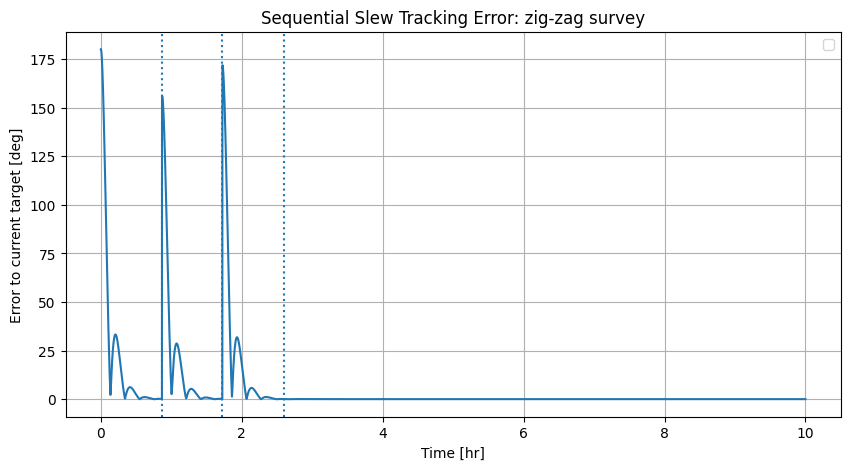

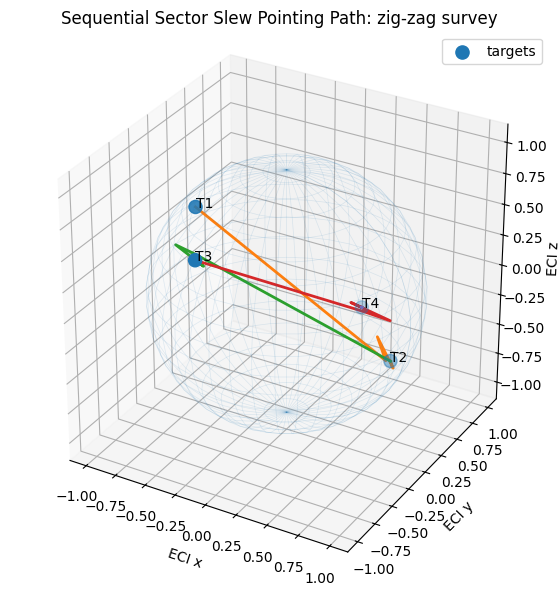

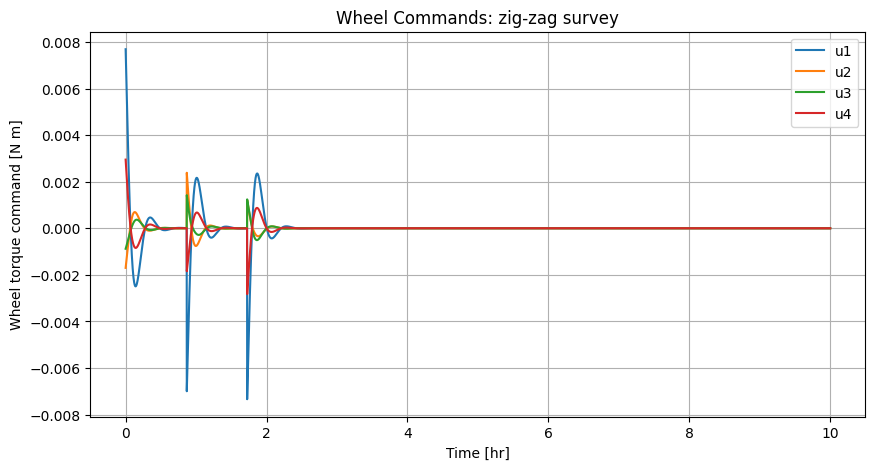

In [74]:
##########  ALL PLOTS  ##############

# ============================================================
# HW5: Settling time vs torque cap
# ============================================================

# plt.figure(figsize=(8,5))

# for scenario_name in target_sets.keys():
#     sub = results_df[results_df["scenario"] == scenario_name]
#     avg = sub.groupby("torque_cap_Nm")["settle_time_hr"].mean()
#     plt.plot(avg.index, avg.values, marker="o", label=scenario_name)

# plt.xlabel("Wheel torque cap [N m]")
# plt.ylabel("Mean settling time [hr]")
# plt.title("Sequential Slew Settling Performance")
# plt.grid(True)
# plt.legend()
# plt.show()

# ============================================================
# HW5: Representative case visualization
# ============================================================

scenario_name = "zig-zag survey"
targets = target_sets[scenario_name]

q0_seq = targets[0]
x0_seq = np.hstack([q0_seq, np.zeros(3)])

seq = simulate_sequential_slews_with_settling(
    x0_seq,
    targets,
    kp=0.006,
    kd=0.6,
    torque_cap=torque_cap,
    reach_tol_deg=reach_tol,
    settle_tol_deg=settle_tol,
    settle_dwell_s=600.0
)

x_seq = seq["x"]
u_seq = seq["u"]
err_seq = seq["err"]
switch_times = seq["switch_times"]
time_hr = t_eval / 3600

switch_times_plot = switch_times[:len(targets)-1]

final_time_hr = switch_times[-1]/3600 + 1.0
mask = time_hr <= final_time_hr

time_hr[mask]
err_seq[mask]
u_seq[:, mask]


########    Tracking error plot    #########

plt.figure(figsize=(10,5))
plt.plot(time_hr[mask], err_seq[mask])

switch_times_plot = switch_times[:len(targets)-1]

for ts in switch_times_plot:
    plt.axvline(ts/3600, linestyle=":")

plt.xlabel("Time [hr]")
plt.ylabel("Error to current target [deg]")
plt.title(f"Sequential Slew Tracking Error: {scenario_name}")
plt.grid(True)
plt.legend()
plt.show()


#######     Pointing-path plot   ########
def pointing_vectors_from_quats(q_hist):
    v = np.zeros((3, q_hist.shape[1]))

    for k in range(q_hist.shape[1]):
        v[:, k] = Q(q_hist[:, k]) @ boresight_B

    return v


def target_vectors_from_quats(targets):
    v = np.zeros((3, len(targets)))

    for i, q in enumerate(targets):
        v[:, i] = Q(q) @ boresight_B

    return v


v_true = pointing_vectors_from_quats(x_seq[0:4, mask])
v_targ = target_vectors_from_quats(targets)

ds = 100

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")

uu = np.linspace(0, 2*np.pi, 40)
vv = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(uu), np.sin(vv))
ys = np.outer(np.sin(uu), np.sin(vv))
zs = np.outer(np.ones_like(uu), np.cos(vv))

# ax.plot(
#     v_targ[0, :],
#     v_targ[1, :],
#     v_targ[2, :],
#     "--",
#     linewidth=1.5,
#     label="nominal"
# )

ax.plot_wireframe(xs, ys, zs, alpha=0.12, linewidth=0.5)

switch_idx = [0]

for ts in switch_times_plot:
    idx = np.argmin(np.abs(time_hr - ts/3600))
    switch_idx.append(idx)

switch_idx.append(v_true.shape[1]-1)

for i in range(len(switch_idx)-1):

    s0 = switch_idx[i]
    s1 = switch_idx[i+1]

    colors = ["tab:orange", "tab:green", "tab:red", "tab:purple"]

    ax.plot(
        v_true[0, s0:s1:ds],
        v_true[1, s0:s1:ds],
        v_true[2, s0:s1:ds],
        linewidth=2,
        color=colors[i % len(colors)]
    )

ax.scatter(v_targ[0, :], v_targ[1, :], v_targ[2, :], s=90, label="targets")

for i in range(v_targ.shape[1]):
    ax.text(v_targ[0, i], v_targ[1, i], v_targ[2, i], f"T{i+1}")

ax.set_xlabel("ECI x")
ax.set_ylabel("ECI y")
ax.set_zlabel("ECI z")
ax.set_title(f"Sequential Sector Slew Pointing Path: {scenario_name}")
ax.set_box_aspect([1,1,1])
ax.legend()
plt.savefig('ZigZagSlew.png')
plt.show()  


######  Wheel command plot  ########
plt.figure(figsize=(10,5))

for i in range(u_seq.shape[0]):
    plt.plot(time_hr[mask], u_seq[i, mask], label=f"u{i+1}")

plt.xlabel("Time [hr]")
plt.ylabel("Wheel torque command [N m]")
plt.title(f"Wheel Commands: {scenario_name}")
plt.grid(True)
plt.legend()
plt.savefig('Wheel Command ZigZag.png')
plt.show()

# ######### Settling time plot  ############
# plt.figure(figsize=(10,5))

# plt.plot(time_hr[mask], err_seq[mask])


# for ts in switch_times_plot:
#     if ts/3600 <= final_time_hr:
#         plt.axvline(ts/3600, linestyle=":")

# plt.xlabel("Time [hr]")
# plt.ylabel("Pointing error [deg]")
# plt.title("Sequential Slew Settling Behavior")
# plt.grid(True)
# plt.legend()
# plt.show()

In [71]:
# plt.figure(figsize=(10,5))

# for scenario_name, targets_i in target_sets.items():
#     q0_i = targets_i[0]
#     x0_i = np.hstack([q0_i, np.zeros(3)])

#     seq_i = simulate_sequential_slews_with_settling(
#         x0_i,
#         targets_i,
#         kp=0.006,
#         kd=0.12,
#         torque_cap=0.01,
#         reach_tol_deg=reach_tol,
#         settle_tol_deg=settle_tol,
#         settle_dwell_s=600.0
#     )

#     err_i = seq_i["err"]
#     switches_i = seq_i["switch_times"]

#     if len(switches_i) > 0:
#         final_i = switches_i[-1]/3600 + 1.0
#     else:
#         final_i = time_hr[-1]

#     mask_i = time_hr <= final_i
#     plt.plot(time_hr[mask_i], err_i[mask_i], label=scenario_name)

# plt.axhline(reach_tol, linestyle="--", label="reach threshold")
# plt.axhline(settle_tol, linestyle="--", label="settle threshold")

# plt.xlabel("Time [hr]")
# plt.ylabel("Error to current target [deg]")
# plt.title("Tracking Error for Different Pointing Configurations")
# plt.grid(True)
# plt.legend()
# plt.show()

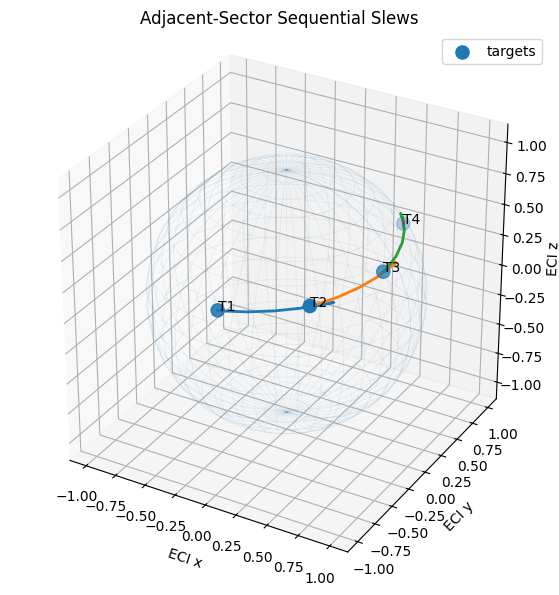

In [72]:
# ============================================================
# Clean visualization: adjacent-sector slews
# ============================================================

scenario_simple = "adjacent sectors"
targets_simple = target_sets[scenario_simple]

q0_simple = targets_simple[0]
x0_simple = np.hstack([q0_simple, np.zeros(3)])

seq_simple = simulate_sequential_slews_with_settling(
    x0_simple,
    targets_simple,
    kp=0.006,
    kd=0.5,
    torque_cap=0.01,
    reach_tol_deg=5.0,
    settle_tol_deg=1.0,
    settle_dwell_s=600.0
)

x_simple = seq_simple["x"]
switch_simple = seq_simple["switch_times"]

time_hr_simple = t_eval / 3600

final_time_simple = switch_simple[-1]/3600 + 1.0
mask_simple = time_hr_simple <= final_time_simple

v_true_simple = pointing_vectors_from_quats(
    x_simple[0:4, mask_simple]
)

v_targ_simple = target_vectors_from_quats(targets_simple)

# heavier downsampling for clean appearance
ds = 20

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")

# sphere
uu = np.linspace(0, 2*np.pi, 40)
vv = np.linspace(0, np.pi, 20)

xs = np.outer(np.cos(uu), np.sin(vv))
ys = np.outer(np.sin(uu), np.sin(vv))
zs = np.outer(np.ones_like(uu), np.cos(vv))

ax.plot_wireframe(xs, ys, zs, alpha=0.10, linewidth=0.5)

# # nominal path
# ax.plot(
#     v_targ_simple[0, :],
#     v_targ_simple[1, :],
#     v_targ_simple[2, :],
#     "--",
#     linewidth=1.5,
#     label="nominal"
# )

# actual slews
switch_idx = [0]

for ts in switch_simple[:len(targets_simple)-1]:
    idx = np.argmin(np.abs(time_hr_simple[mask_simple] - ts/3600))
    switch_idx.append(idx)

switch_idx.append(v_true_simple.shape[1]-1)

for i in range(len(switch_idx)-1):

    s0 = switch_idx[i]
    s1 = switch_idx[i+1]

    ax.plot(
        v_true_simple[0, s0:s1:ds],
        v_true_simple[1, s0:s1:ds],
        v_true_simple[2, s0:s1:ds],
        linewidth=2
    )

# targets
ax.scatter(
    v_targ_simple[0, :],
    v_targ_simple[1, :],
    v_targ_simple[2, :],
    s=90,
    label="targets"
)

for i in range(v_targ_simple.shape[1]):
    ax.text(
        v_targ_simple[0, i],
        v_targ_simple[1, i],
        v_targ_simple[2, i],
        f"T{i+1}"
    )

ax.set_xlabel("ECI x")
ax.set_ylabel("ECI y")
ax.set_zlabel("ECI z")

ax.set_title("Adjacent-Sector Sequential Slews")
ax.set_box_aspect([1,1,1])

ax.legend()
plt.savefig('AdjacentSlews.png')
plt.show()

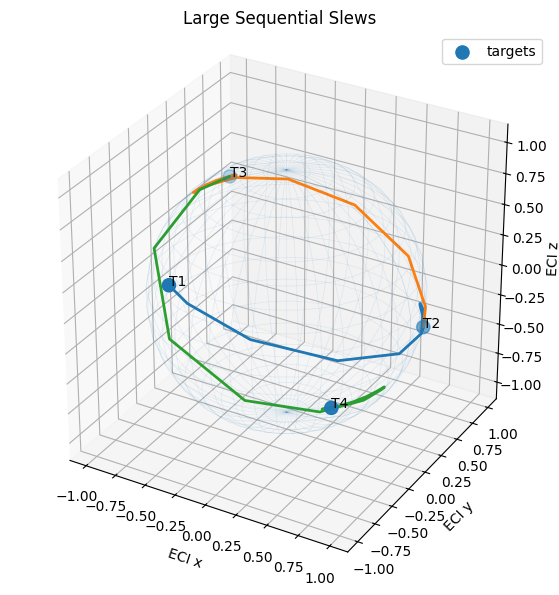

In [70]:
# ============================================================
# Clean visualization: adjacent-sector slews
# ============================================================

scenario_simple = "large slews"
targets_simple = target_sets[scenario_simple]

q0_simple = targets_simple[0]
x0_simple = np.hstack([q0_simple, np.zeros(3)])

seq_simple = simulate_sequential_slews_with_settling(
    x0_simple,
    targets_simple,
    kp=0.006,
    kd=0.65,
    torque_cap=0.01,
    reach_tol_deg=5.0,
    settle_tol_deg=1.0,
    settle_dwell_s=600.0
)

x_simple = seq_simple["x"]
switch_simple = seq_simple["switch_times"]

time_hr_simple = t_eval / 3600

final_time_simple = switch_simple[-1]/3600 + 1.0
mask_simple = time_hr_simple <= final_time_simple

v_true_simple = pointing_vectors_from_quats(
    x_simple[0:4, mask_simple]
)

v_targ_simple = target_vectors_from_quats(targets_simple)

# heavier downsampling for clean appearance
ds = 20

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")

# sphere
uu = np.linspace(0, 2*np.pi, 40)
vv = np.linspace(0, np.pi, 20)

xs = np.outer(np.cos(uu), np.sin(vv))
ys = np.outer(np.sin(uu), np.sin(vv))
zs = np.outer(np.ones_like(uu), np.cos(vv))

ax.plot_wireframe(xs, ys, zs, alpha=0.10, linewidth=0.5)

# # nominal path
# ax.plot(
#     v_targ_simple[0, :],
#     v_targ_simple[1, :],
#     v_targ_simple[2, :],
#     "--",
#     linewidth=1.5,
#     label="nominal"
# )

# actual slews
switch_idx = [0]

for ts in switch_simple[:len(targets_simple)-1]:
    idx = np.argmin(np.abs(time_hr_simple[mask_simple] - ts/3600))
    switch_idx.append(idx)

switch_idx.append(v_true_simple.shape[1]-1)

for i in range(len(switch_idx)-1):

    s0 = switch_idx[i]
    s1 = switch_idx[i+1]

    ax.plot(
        v_true_simple[0, s0:s1:ds],
        v_true_simple[1, s0:s1:ds],
        v_true_simple[2, s0:s1:ds],
        linewidth=2
    )

# targets
ax.scatter(
    v_targ_simple[0, :],
    v_targ_simple[1, :],
    v_targ_simple[2, :],
    s=90,
    label="targets"
)

for i in range(v_targ_simple.shape[1]):
    ax.text(
        v_targ_simple[0, i],
        v_targ_simple[1, i],
        v_targ_simple[2, i],
        f"T{i+1}"
    )

ax.set_xlabel("ECI x")
ax.set_ylabel("ECI y")
ax.set_zlabel("ECI z")

ax.set_title("Large Sequential Slews")
ax.set_box_aspect([1,1,1])

ax.legend()
plt.savefig('LargeSlews.png')
plt.show()